## Criando uma distribuição de probabilidade de imagens
- A distribuição será baseada nos pixels, como a minha imagem é em escala de cinza e os pixels variam entre (0 - 255) farei a distribuição de probabilidade de cada pixel, por exemplo (\sum(5))/(Quantidade_de_pixels), \sum(5) sendo a quantidade de vezes que o pixel 5 aparece. 

### Bibliotecas

In [12]:
import cv2
import os
import numpy as np 
import matplotlib.pyplot as plt

### Path das imagens NELORE

In [17]:
path_img_nelore = '/home/victors/Documents/Codigos_Mestrado/banco2/Nelore/imgs/'
files = os.listdir(path_img_nelore)

In [18]:
# Carrega a imagem em escala de cinza
all_pixels_n = []
for file in files:
    img = cv2.imread(os.path.join(path_img_nelore, file), cv2.IMREAD_GRAYSCALE)
    all_pixels_n.extend(img.flatten())
all_pixels_n = np.array(all_pixels_n)

### Path das imagens CARACU

In [19]:
path_img_nelore = '/home/victors/Documents/Codigos_Mestrado/banco2/CARACU_1/imgs/'
files = os.listdir(path_img_nelore)

In [20]:
# Carrega a imagem em escala de cinza
all_pixels_c = []
for file in files:
    img = cv2.imread(os.path.join(path_img_nelore, file), cv2.IMREAD_GRAYSCALE)
    all_pixels_c.extend(img.flatten())
all_pixels_c = np.array(all_pixels_c)

### Calcula o histograma

In [23]:
# Nelore
hist_n = np.bincount(all_pixels_n, minlength=256)
# Normaliza o histograma ~ o histograma vira uma distribuição de probabilidade
hist_normalized_n = hist_n / hist_n.sum()

In [22]:
# Caracu
hist_c = np.bincount(all_pixels_c, minlength=256)
# Normaliza o histograma ~ o histograma vira uma distribuição de probabilidade
hist_normalized_c = hist_c / hist_c.sum()

### Plot do gráfico

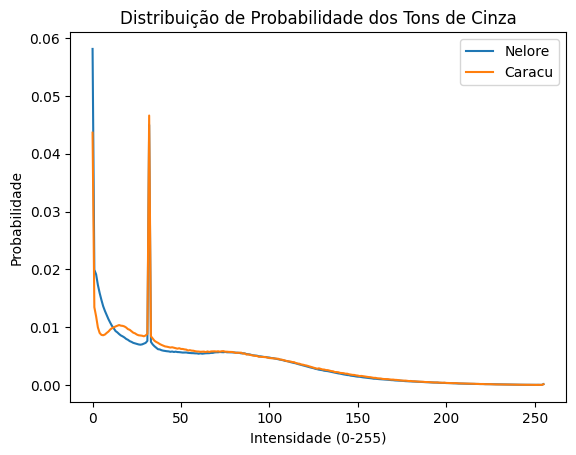

In [25]:
plt.plot(hist_normalized_n, label='Nelore')
plt.plot(hist_normalized_c, label='Caracu')
plt.title('Distribuição de Probabilidade dos Tons de Cinza')
plt.xlabel('Intensidade (0-255)')
plt.ylabel('Probabilidade')
plt.legend()
plt.savefig('distribuicao_tons_cinza_NC.png', dpi=300, bbox_inches='tight')
plt.show()

### Diferença dos gráficos

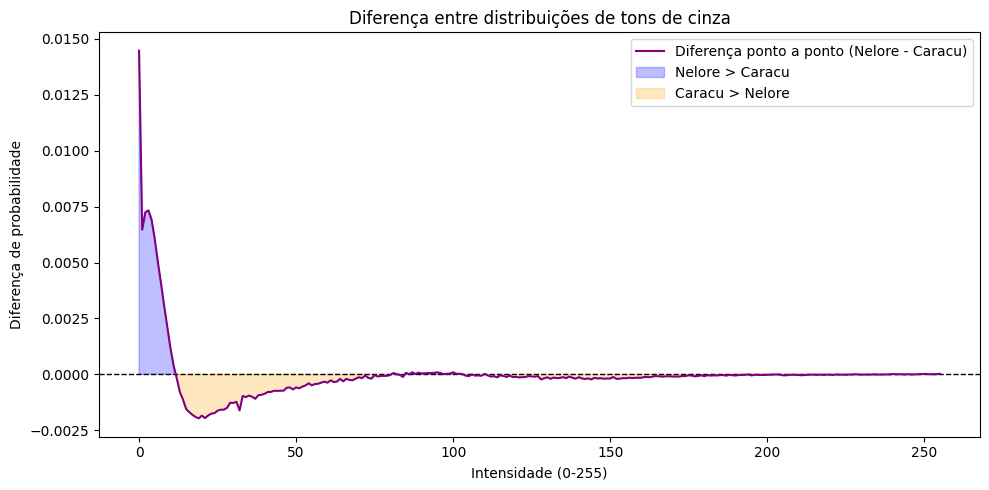

In [29]:
## Calcula a diferença entre as distribuições
x = np.arange(256)

diff = hist_normalized_n - hist_normalized_c
diff_abs = np.abs(diff)

plt.figure(figsize=(10, 5))
plt.axhline(0, color='black', linewidth=1, linestyle='--')
plt.plot(x, diff, label='Diferença ponto a ponto (Nelore - Caracu)', color='purple')
plt.fill_between(x, 0, diff, where=(diff >= 0), alpha=0.25, color='blue', label='Nelore > Caracu')
plt.fill_between(x, 0, diff, where=(diff < 0), alpha=0.25, color='orange', label='Caracu > Nelore')
plt.title('Diferença entre distribuições de tons de cinza')
plt.xlabel('Intensidade (0-255)')
plt.ylabel('Diferença de probabilidade')
plt.legend()
plt.tight_layout()
plt.savefig('diferenca_distribuicao_tons_cinza_NC.png', dpi=300, bbox_inches='tight')
plt.show()

In [28]:
# Métricas simples de diferença
l1 = diff_abs.sum()
l2 = np.sqrt((diff**2).sum())
max_diff = diff_abs.max()
idx_max = diff_abs.argmax()

print(f"L1 (diferença total): {l1:.6f}")
print(f"L2 (distância euclidiana): {l2:.6f}")
print(f"Maior diferença em intensidade {idx_max}: {max_diff:.6f}")

L1 (diferença total): 0.130703
L2 (distância euclidiana): 0.023829
Maior diferença em intensidade 0: 0.014475


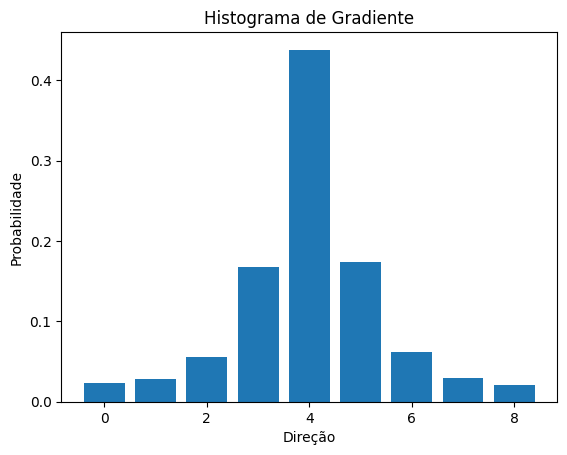

In [30]:
path_img = '/home/victors/Documents/Codigos_Mestrado/banco2/teste/imgs/I-2519-251119-162630.jpg'
img = cv2.imread(path_img, cv2.IMREAD_GRAYSCALE)

# Gradientes em x e y
gx = cv2.Sobel(img, cv2.CV_64F, 1, 0)
gy = cv2.Sobel(img, cv2.CV_64F, 0, 1)

# Magnitude e direção
magnitude = np.sqrt(gx**2 + gy**2)
angle = np.arctan2(gy, gx)  # radianos

# Converter ângulo para graus (0 a 180)
angle_deg = np.degrees(angle) % 180

# Criar histograma de direções
hist, bins = np.histogram(angle_deg, bins=9, range=(0,180), weights=magnitude)

# Normalizar
hist = hist / hist.sum()

plt.bar(range(9), hist)
plt.title("Histograma de Gradiente")
plt.xlabel("Direção")
plt.ylabel("Probabilidade")
plt.show()